# Notebook 03: Exploratory Data Analysis

## Objective

This notebook explores relationships between demographic, socioeconomic, lifestyle and clinical factors and body mass index (BMI) among adult NHANES participants.

BMI (BMXBMI) is the primary continuous outcome for regression modelling. Obesity status (BMI ≥ 30 kg/m²) is included only for descriptive purposes.

The EDA aims to identify patterns, potential associations, important predictors and modelling considerations before machine-learning regression analysis.

### Step 1. Import Libraries, Load and Inspect the Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../outputs/NHANES_Cleaned_Adults.csv")

In [2]:
# Check the data size
print("Dataset shape:", df.shape)

Dataset shape: (16943, 48)


In [3]:
# Look at the first few rows
df.head()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,DMDMARTL,INDFMPIR,BMXBMI,BMXWAIST,BPXSY1,...,Congestive_Heart_Failure,Coronary_Heart_Disease,Heart_Attack,Stroke,Vigorous_Work_Activity,Moderate_Work_Activity,Vigorous_Recreational_Activity,Weight_Change_Intent,Depressed_Hopeless,Drug_Use
0,73557.0,69.0,1.0,4.0,3.0,4.0,0.84,26.7,100.0,122.0,...,No,No,No,Yes,No,No,No,Not trying,Not at all,Unknown
1,73558.0,54.0,1.0,3.0,3.0,1.0,1.78,28.6,107.6,156.0,...,No,No,No,No,No,Yes,No,Not trying,Not at all,Yes
2,73559.0,72.0,1.0,3.0,4.0,1.0,4.51,28.9,109.2,140.0,...,No,No,No,No,No,Yes,No,Not trying,Not at all,Unknown
3,73561.0,73.0,2.0,3.0,5.0,1.0,5.00,19.7,NaN,136.0,...,No,No,No,No,No,Yes,No,No,Several days,Unknown
4,73562.0,56.0,1.0,1.0,4.0,3.0,4.79,41.7,123.1,160.0,...,No,Yes,Yes,No,Yes,No,No,Yes,Nearly every day,Yes


In [4]:
# Look at the last few rows
df.tail()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,DMDMARTL,INDFMPIR,BMXBMI,BMXWAIST,BPXSY1,...,Congestive_Heart_Failure,Coronary_Heart_Disease,Heart_Attack,Stroke,Vigorous_Work_Activity,Moderate_Work_Activity,Vigorous_Recreational_Activity,Weight_Change_Intent,Depressed_Hopeless,Drug_Use
16938,102949.0,33.0,1.0,3.0,3.0,6.0,1.01,23.7,85.5,120.0,...,No,No,No,No,Yes,Yes,No,Not trying,Not at all,Yes
16939,102952.0,70.0,2.0,6.0,3.0,1.0,0.95,20.0,82.2,136.0,...,No,No,No,No,No,No,No,Not trying,Not at all,Unknown
16940,102953.0,42.0,1.0,1.0,3.0,4.0,NaN,35.8,114.8,124.0,...,No,No,No,No,Yes,Yes,No,Yes,Several days,No
16941,102954.0,41.0,2.0,4.0,5.0,5.0,1.18,26.1,86.4,116.0,...,No,No,No,No,No,No,No,Not trying,Not at all,No
16942,102956.0,38.0,1.0,3.0,4.0,3.0,1.56,36.1,122.0,150.0,...,No,No,No,No,No,No,No,Yes,Several days,Yes


In [5]:
print("Participants:", df["SEQN"].nunique())
print("Mean age:", round(df["RIDAGEYR"].mean(), 1))
print("Mean BMI:", round(df["BMXBMI"].mean(), 2))
print("Obesity prevalence:",
      round(df["Obesity"].mean() * 100, 2),"%")

Participants: 16943
Mean age: 48.3
Mean BMI: 29.32
Obesity prevalence: 39.15 %


### Step 2. Study Population Characteristics

In [6]:
# Major demographic variables
print("Sex distribution:")
print(df["Sex"].value_counts())

print("\nRace/Ethnicity:")
print(df["Race_Ethnicity"].value_counts())

print("\nEducation:")
print(df["Education"].value_counts())

Sex distribution:
Sex
Female    8811
Male      8132
Name: count, dtype: int64

Race/Ethnicity:
Race_Ethnicity
Non-Hispanic White    6138
Non-Hispanic Black    3675
Mexican American      2553
Non-Hispanic Asian    2131
Other Hispanic        1770
Other/Multi-Racial     676
Name: count, dtype: int64

Education:
Education
Some college/AA degree       4974
College graduate or above    3986
High school/GED              3635
9-11th grade                 1974
Less than 9th grade          1515
Name: count, dtype: int64


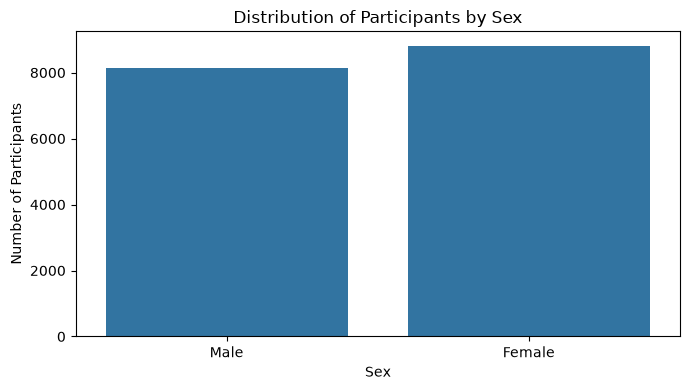

In [7]:
# One demographic figure
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="Sex"
)

plt.title("Distribution of Participants by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Participants")

plt.tight_layout()
plt.show()

The analytical sample included slightly more female than male participants and represented multiple racial/ethnic and educational groups. These characteristics were subsequently examined in relation to BMI.

### Step 3. BMI Distribution and Obesity Prevalence

The distribution of BMI was examined before investigating its relationships with demographic, socioeconomic, lifestyle and clinical factors. The BMI ≥ 30 kg/m² threshold is shown for descriptive context.

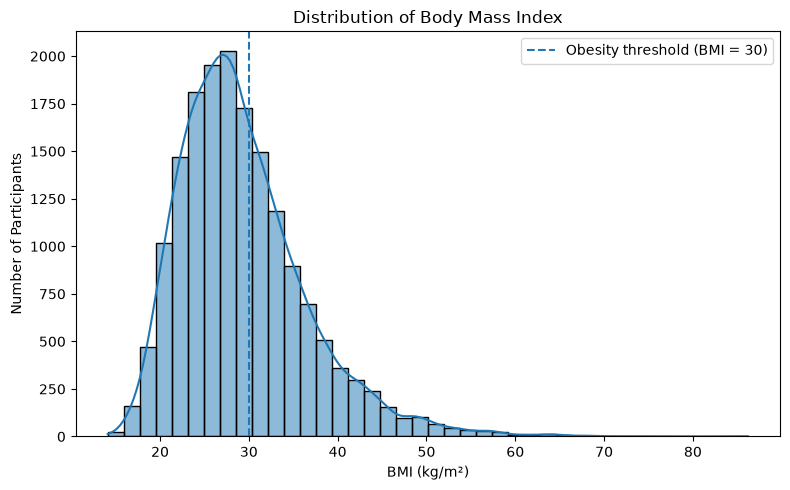

In [8]:
# Histogram showing BMI distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="BMXBMI",
    bins=40,
    kde=True
)

plt.axvline(
    30,
    linestyle="--",
    label="Obesity threshold (BMI = 30)"
)

plt.title("Distribution of Body Mass Index")
plt.xlabel("BMI (kg/m²)")
plt.ylabel("Number of Participants")
plt.legend()

plt.tight_layout()
plt.show()

BMI showed a right-skewed distribution, with most participants concentrated in the mid-range and a smaller number exhibiting substantially higher BMI values. The dashed line indicates the BMI ≥ 30 kg/m² threshold used to define obesity descriptively.

In [9]:
# Obesity prevalence
obesity_counts = (
    df["Obesity"]
    .value_counts()
    .sort_index()
)

obesity_percent = (
    df["Obesity"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(pd.DataFrame({
    "Count": obesity_counts,
    "Percentage": obesity_percent.round(2)
}))

         Count  Percentage
Obesity                   
0        10309       60.85
1         6634       39.15


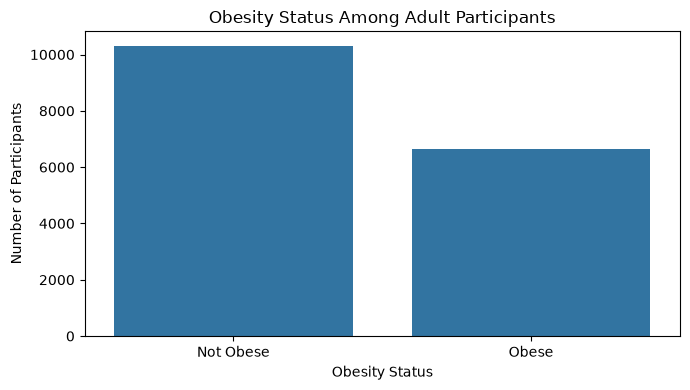

In [10]:
# Barchart showing distribution of obesity
plot_df = df.copy()

plot_df["Obesity_Status"] = plot_df["Obesity"].map({
    0: "Not Obese",
    1: "Obese"
})

plt.figure(figsize=(7, 4))

sns.countplot(
    data=plot_df,
    x="Obesity_Status"
)

plt.title("Obesity Status Among Adult Participants")
plt.xlabel("Obesity Status")
plt.ylabel("Number of Participants")

plt.tight_layout()
plt.show()

The mean BMI of the analytical sample was 29.32 kg/m². Using BMI ≥ 30 kg/m² as a descriptive threshold, 39.15% of participants were classified as obese and 60.85% as non-obese. These percentages describe the analytical sample and should not be interpreted as survey-weighted estimates of obesity prevalence in the U.S. population.

### Step 4. Demographic and Socioeconomic Factors Associated with BMI

BMI was examined across key demographic and socioeconomic characteristics, including age, sex, race/ethnicity, education and income-to-poverty ratio. These analyses were used to identify patterns that may be relevant for subsequent regression modelling.

In [11]:
# 4.1.1. BMI by sex
bmi_sex = (
   df.groupby("Sex")["BMXBMI"]
    .agg(["count", "mean", "median", "std"])
    .round(2) 
)

bmi_sex

,count,mean,median,std
Sex,,,,
Female,8811,29.83,28.5,7.94
Male,8132,28.77,27.8,6.37


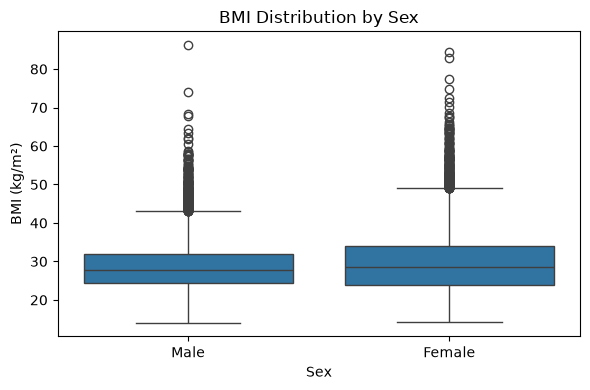

In [12]:
# 4.1.2. BMI Distribution by sex
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="Sex",
    y="BMXBMI"
)

plt.title("BMI Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("BMI (kg/m²)")
plt.tight_layout()
plt.show()

Female participants had a slightly higher mean BMI (29.83 kg/m²) than male participants (28.77 kg/m²). Both groups showed considerable variation in BMI, including high values beyond the boxplot whiskers. These differences are descriptive and unadjusted.

In [13]:
# 4.2.1. BMI by race/ethnicity
bmi_race = (
    df.groupby("Race_Ethnicity")["BMXBMI"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
    .round(2)
)

bmi_race

,count,mean,median
Race_Ethnicity,,,
Non-Hispanic Black,3675,30.62,29.3
Mexican American,2553,30.60,29.6
Other/Multi-Racial,676,30.15,28.9
Other Hispanic,1770,29.42,28.6
Non-Hispanic White,6138,29.30,28.0
Non-Hispanic Asian,2131,25.27,24.6


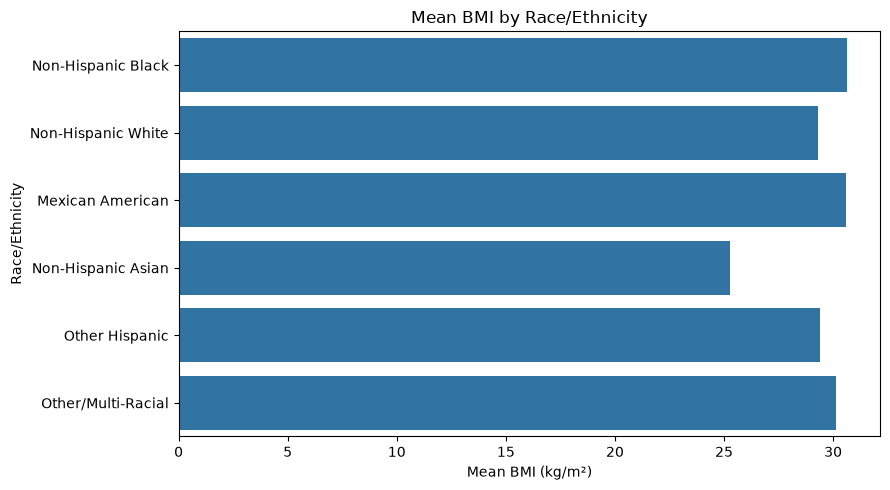

In [14]:
# 4.2.2. Mean BMI by race/ethnicity
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    y="Race_Ethnicity",
    x="BMXBMI",
    estimator="mean",
    errorbar=None
)

plt.title("Mean BMI by Race/Ethnicity")
plt.xlabel("Mean BMI (kg/m²)")
plt.ylabel("Race/Ethnicity")
plt.tight_layout()
plt.show()

Mean BMI varied across racial/ethnic groups, ranging from 25.27 kg/m² among non-Hispanic Asian participants to 30.62 kg/m² among non-Hispanic Black participants. Mexican American participants had a similarly high mean BMI of 30.60 kg/m². These differences are descriptive and unadjusted and should not be interpreted as causal

In [15]:
# 4.3.1. BMI by level of education
education_order = [
    "Less than 9th grade",
    "9-11th grade",
    "High school/GED",
    "Some college/AA degree",
    "College graduate or above"
]

bmi_education = (
    df.groupby("Education")["BMXBMI"]
    .mean()
    .reindex(education_order)
    .round(2)
)

bmi_education

Education
Less than 9th grade          29.62
9-11th grade                 29.34
High school/GED              29.91
Some college/AA degree       30.34
College graduate or above    28.07
Name: BMXBMI, dtype: float64

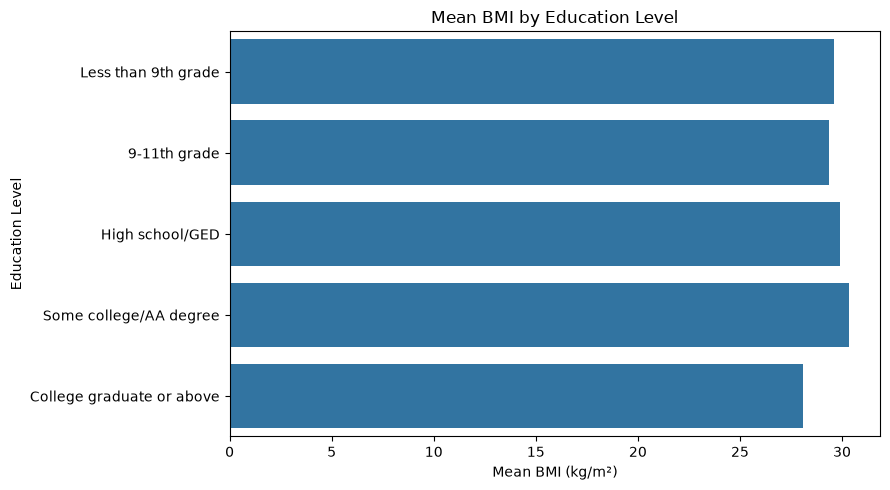

In [16]:
# 4.3.2. Mean BMI by level of education
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    y="Education",
    x="BMXBMI",
    order=education_order,
    estimator="mean",
    errorbar=None
)

plt.title("Mean BMI by Education Level")
plt.xlabel("Mean BMI (kg/m²)")
plt.ylabel("Education Level")
plt.tight_layout()
plt.show()

Mean BMI varied modestly across education levels. Participants with some college/AA education had the highest mean BMI (30.34 kg/m²), while college graduates or above had the lowest (28.07 kg/m²). The pattern was not consistently linear across increasing education levels and represents an unadjusted descriptive association.

In [17]:
# 4.4. Age and Income-to-Poverty Ratio vs BMI
print(
    "Age vs BMI correlation:",
    round(df["RIDAGEYR"].corr(df["BMXBMI"]), 3)
)

print(
    "Income-to-poverty ratio vs BMI correlation:",
    round(df["INDFMPIR"].corr(df["BMXBMI"]), 3)
)

Age vs BMI correlation: 0.053
Income-to-poverty ratio vs BMI correlation: -0.065


Age showed a very weak positive linear correlation with BMI (r = 0.053), while income-to-poverty ratio showed a very weak negative correlation (r = −0.065). These results suggest that neither age nor income-to-poverty ratio alone had a strong linear relationship with BMI in this analytical sample. These associations are descriptive and do not establish causality.

### Step 5. Lifestyle Factors and BMI

In [18]:
# 5.1. Mean BMI by Lifestyle Characteristics
lifestyle_vars = [
    "Smoked_100_Cigarettes",
    "Vigorous_Work_Activity",
    "Moderate_Work_Activity",
    "Vigorous_Recreational_Activity",
    "Drug_Use",
    "Weight_Change_Intent"
]

for var in lifestyle_vars:
    print(f"\n--- {var} ---")
    
    result = (
        df.groupby(var)["BMXBMI"]
        .agg(["count", "mean", "median"])
        .round(2)
    )
    
    print(result)


--- Smoked_100_Cigarettes ---
                       count   mean  median
Smoked_100_Cigarettes                      
No                     10001  29.17    28.0
Yes                     6931  29.54    28.4

--- Vigorous_Work_Activity ---
                        count   mean  median
Vigorous_Work_Activity                      
No                      13376  29.23    28.0
Yes                      3558  29.66    28.6

--- Moderate_Work_Activity ---
                        count   mean  median
Moderate_Work_Activity                      
No                      10536  29.09    27.9
Yes                      6395  29.71    28.6

--- Vigorous_Recreational_Activity ---
                                count   mean  median
Vigorous_Recreational_Activity                      
No                              12775  29.83    28.7
Yes                              4167  27.75    26.6

--- Drug_Use ---
          count   mean  median
Drug_Use                      
No         4826  29.33    28.0
Unknow

In [19]:
# 5.2. Sedentary Time and BMI
sedentary_corr = df["PAD680"].corr(df["BMXBMI"])

print(
    "Sedentary time vs BMI correlation:",
    round(sedentary_corr, 3)
)

Sedentary time vs BMI correlation: 0.081


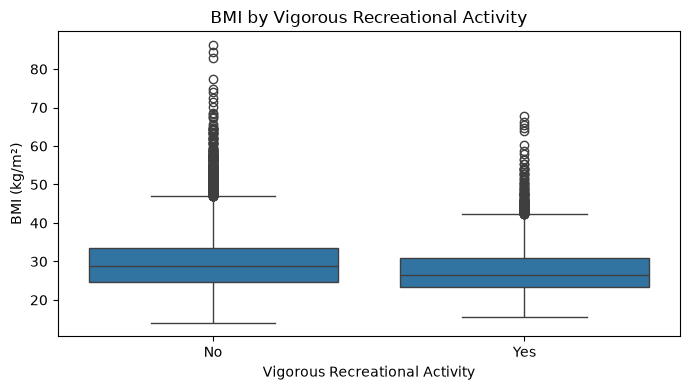

In [20]:
# 5.3. BMI by Vigorous Recreational Activity
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Vigorous_Recreational_Activity",
    y="BMXBMI"
)

plt.title("BMI by Vigorous Recreational Activity")
plt.xlabel("Vigorous Recreational Activity")
plt.ylabel("BMI (kg/m²)")

plt.tight_layout()
plt.show()

Participants reporting vigorous recreational activity had a lower mean BMI (27.75 kg/m²) than those reporting no vigorous recreational activity (29.83 kg/m²). Smaller differences were observed for smoking, work-related physical activity and drug-use history. Sedentary time showed only a very weak positive linear correlation with BMI (r = 0.081).

The largest descriptive difference was observed for weight-change intention. Participants reporting an intention to change their weight had a substantially higher mean BMI (33.49 kg/m²) than those who were not trying to change their weight (25.41 kg/m²) or reported “No” (21.65 kg/m²). This association should be interpreted cautiously because weight-change intention may be a response to existing body weight rather than a cause of higher BMI. These findings are descriptive and do not establish causal relationships.

### Step 6. Clinical Factors and BMI

In [21]:
# 6.1 BMI by Diabetes and Cardiovascular Conditions
clinical_vars = [
    "Diabetes",
    "Prediabetes",
    "Arthritis",
    "Congestive_Heart_Failure",
    "Coronary_Heart_Disease",
    "Heart_Attack",
    "Stroke"
]

for var in clinical_vars:
    print(f"\n--- {var} ---")
    
    result = (
        df.groupby(var)["BMXBMI"]
        .agg(["count", "mean", "median"])
        .round(2)
    )
    
    print(result)


--- Diabetes ---
            count   mean  median
Diabetes                        
Borderline    457  31.62    30.3
No          14172  28.74    27.6
Yes          2303  32.44    31.1

--- Prediabetes ---
             count   mean  median
Prediabetes                      
No           12872  28.43   27.35
Yes           1289  31.76   30.40

--- Arthritis ---
           count   mean  median
Arthritis                      
No         11666  28.75    27.7
Yes         4400  31.45    30.2

--- Congestive_Heart_Failure ---
                          count   mean  median
Congestive_Heart_Failure                      
No                        15533  29.39    28.2
Yes                         537  32.56    31.4

--- Coronary_Heart_Disease ---
                        count   mean  median
Coronary_Heart_Disease                      
No                      15377  29.46    28.2
Yes                       670  30.16    29.2

--- Heart_Attack ---
              count   mean  median
Heart_Attack          

In [22]:
# 6.2 Correlations Between Continuous Clinical Measurements and BMI
clinical_continuous = [
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBDHDD",
    "LBXTC",
    "LBXGH"
]

clinical_correlations = (
    df[clinical_continuous + ["BMXBMI"]]
    .corr()["BMXBMI"]
    .drop("BMXBMI")
    .sort_values(ascending=False)
    .round(3)
)

clinical_correlations

BMXWAIST    0.910
LBXGH       0.204
BPXSY1      0.135
BPXDI1      0.122
LBXTC       0.024
LBDHDD     -0.270
Name: BMXBMI, dtype: float64

BMI differed across several clinical groups. Participants with diabetes had a higher mean BMI (32.44 kg/m²) than participants without diabetes (28.74 kg/m²). Higher mean BMI was also observed among participants with prediabetes, arthritis and congestive heart failure.

Among continuous clinical measurements, waist circumference showed by far the strongest linear correlation with BMI (r = 0.910). HbA1c showed a weaker positive correlation (r = 0.204), while systolic and diastolic blood pressure showed weak positive correlations. 

HDL cholesterol was negatively correlated with BMI (r = −0.270), whereas total cholesterol showed almost no linear correlation (r = 0.024).

The very strong relationship between waist circumference and BMI suggests that waist circumference may substantially influence subsequent BMI prediction models. These findings are descriptive and do not establish causal relationships.

### Step 7. Correlation Heatmap

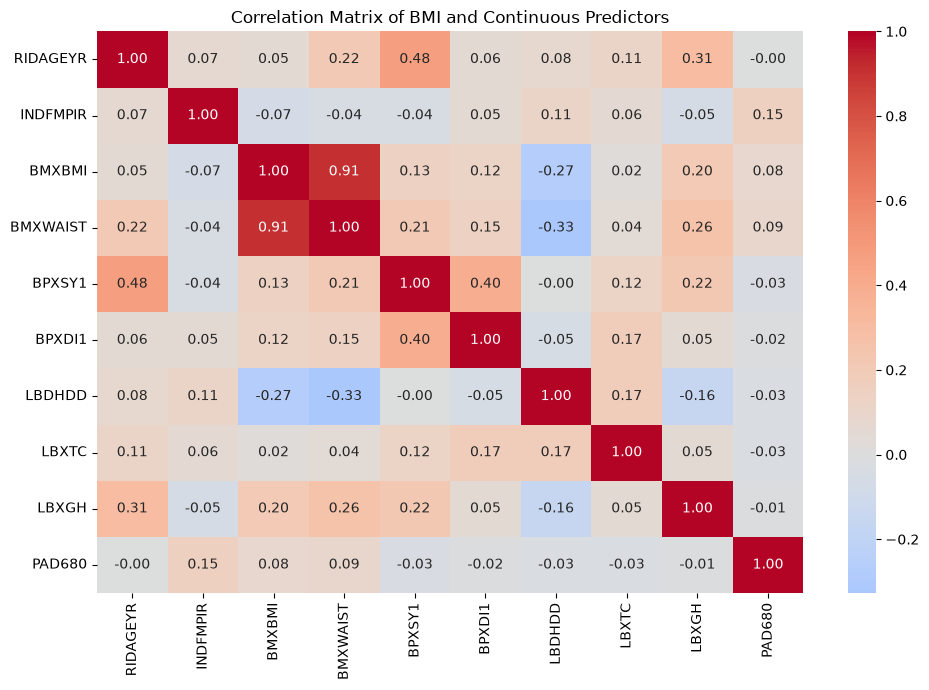

In [23]:
# 7.1 Correlation Heatmap Using NHANES Variable Codes

continuous_eda = [
    "RIDAGEYR",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBDHDD",
    "LBXTC",
    "LBXGH",
    "PAD680"
]

corr_matrix = df[continuous_eda].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of BMI and Continuous Predictors")
plt.tight_layout()
plt.show()

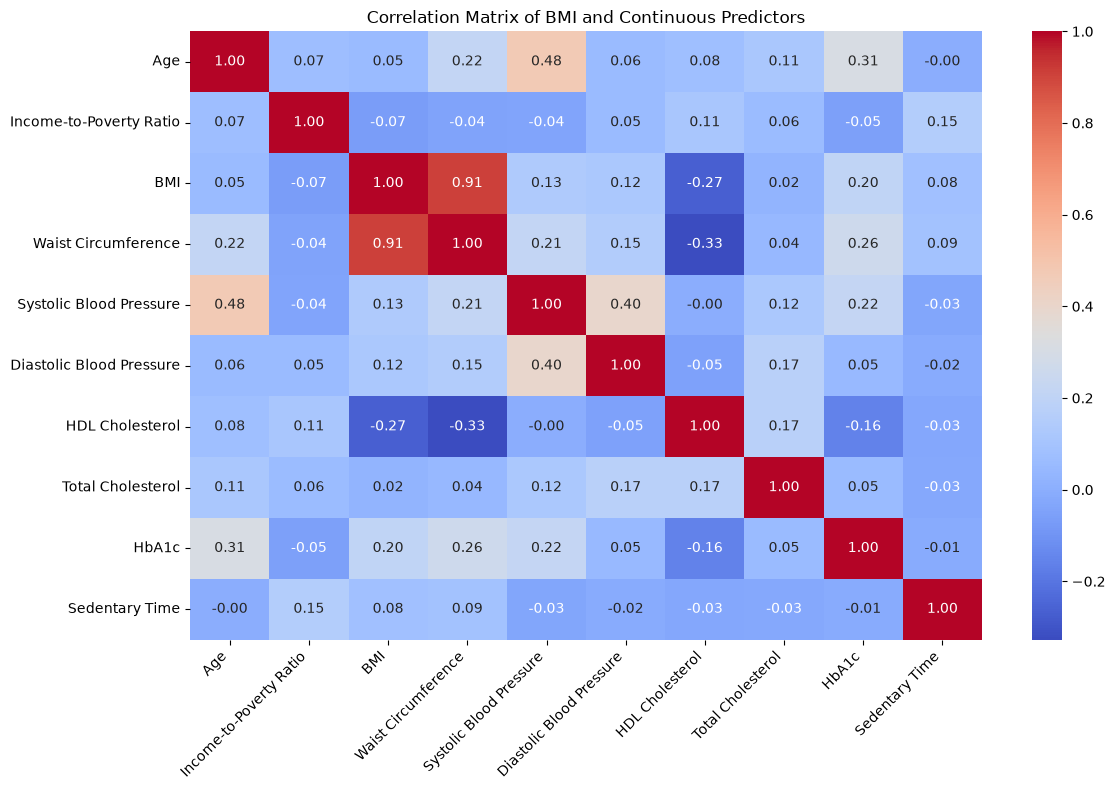

In [24]:
# 7.2 Correlation Heatmap with Readable Variable Labels

# Select the numerical variables for the correlation matrix
corr_cols = [
    'RIDAGEYR',
    'INDFMPIR',
    'BMXBMI',
    'BMXWAIST',
    'BPXSY1',
    'BPXDI1',
    'LBDHDD',
    'LBXTC',
    'LBXGH',
    'PAD680'
]

# Calculate correlation matrix
corr_matrix = df[corr_cols].corr()

# Create readable names
readable_names = {
    'RIDAGEYR': 'Age',
    'INDFMPIR': 'Income-to-Poverty Ratio',
    'BMXBMI': 'BMI',
    'BMXWAIST': 'Waist Circumference',
    'BPXSY1': 'Systolic Blood Pressure',
    'BPXDI1': 'Diastolic Blood Pressure',
    'LBDHDD': 'HDL Cholesterol',
    'LBXTC': 'Total Cholesterol',
    'LBXGH': 'HbA1c',
    'PAD680': 'Sedentary Time'
}

# Replace NHANES codes with readable labels
corr_readable = corr_matrix.rename(
    index=readable_names,
    columns=readable_names
)

# Plot the heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_readable,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Correlation Matrix of BMI and Continuous Predictors")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Key Findings from EDA

- Waist circumference showed by far the strongest linear relationship with BMI (r = 0.910).
- HDL cholesterol was negatively correlated with BMI (r = −0.270).
- HbA1c showed a modest positive correlation with BMI (r = 0.204).
- Systolic and diastolic blood pressure showed weak positive correlations with BMI.
- Age, income-to-poverty ratio and sedentary time showed very weak linear relationships with BMI.
- BMI varied descriptively across sex, race/ethnicity, education, lifestyle and several clinical-condition groups.
- Participants reporting vigorous recreational activity had a lower mean BMI than those reporting no vigorous recreational activity.
- Weight-change intention showed a substantial descriptive relationship with BMI, although reverse causation is possible.

These exploratory findings informed the subsequent regression modelling. In particular, the very strong correlation between waist circumference and BMI indicated that model performance should be evaluated both with and without waist circumference. The observed associations are descriptive and should not be interpreted as causal.